# What trend really costs

Every trend result so far used a provisional cost of 7.5 bps each way on coins trading at least \$10M a day and 15 bps below that. This notebook measures cost instead, then reruns the key books with it.

A taker pays three things on every trade. The exchange fee, 5 bps on Binance USD-M. Half the spread, the gap between the best bid and ask. And impact, how far the price moves while the order eats through the book. The fee is known. The other two are measured.

- Half spread comes from the trade tape. Every trade is tagged with which side started it. In each minute, the average price of buyer-started trades minus the average price of seller-started trades is one spread. The median across the day's minutes is the day's spread.
- Impact comes from book depth, the dollars resting within 1% of the mid price, sampled every 30 seconds.

The sample is four dates, 10 March 2023, 2024 and 2025 and 10 June 2026, two days each, with about 20 coins per date drawn across liquidity bands from BTC-sized down to \$300k a day.

## The measurements

Load the measured sample, cached after its first stream. Drop Binance's composite index perps, the stablecoin pair, non-crypto perps, and any coin where the spread estimate came out negative, which happens when a coin trades too rarely for the estimator.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import costs, panel, stream

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8a86'

raw = costs.sample(['2023-03-10', '2024-03-10', '2025-03-10', '2026-06-10'])
sample = costs.clean(raw)
print(f'coin-dates measured {len(raw)}   kept {len(sample)}   with depth {sample.depth_1pct_usd.notna().sum()}')
print('dropped', sorted(set(raw.symbol) - set(sample.symbol)))
print()
show = sample.assign(liquidity_M=sample.liquidity / 1e6, depth_k=sample.depth_1pct_usd / 1e3)
print(show[['start', 'symbol', 'liquidity_M', 'half_spread_bps', 'depth_k', 'trades']].sort_values(['start', 'liquidity_M'], ascending=[True, False]).round(2).to_string(index=False))

coin-dates measured 80   kept 72   with depth 72
dropped ['BLUEBIRDUSDT', 'DEFIUSDT', 'FOOTBALLUSDT', 'USDCUSDT']

     start         symbol  liquidity_M  half_spread_bps   depth_k  trades
2023-03-10        SOLUSDT       605.04             0.21   2074.67 1110288
2023-03-10      MATICUSDT       552.70             0.41   2897.38  758154
2023-03-10       DOGEUSDT       475.46             0.64   2673.08  339992
2023-03-10        ADAUSDT       274.23             1.37   2382.08  263251
2023-03-10        CRVUSDT       165.21             5.06    755.94  148403
2023-03-10      SUSHIUSDT        53.80             3.53    482.09  100104
2023-03-10        C98USDT        31.51             1.50    167.07   80269
2023-03-10     PEOPLEUSDT        30.73             1.54    269.97   84669
2023-03-10      LUNA2USDT        27.15             0.14    244.70  196888
2023-03-10        ONEUSDT        24.09             1.96    187.06   71073
2023-03-10       REEFUSDT        20.08             1.20    144.26   698

72 coin-dates survive after cleaning, all 72 with depth. Spreads are tight. Coins trading over \$100M a day mostly pay under half a basis point, \$1M to \$10M coins mostly pay 0.5 to 3 bps, and the widest thin names reach 6 to 15 bps.

## The 2026 book depth format

The book depth files changed format on 14 January 2026. Stream a day either side of the change and a recent day, and read what the source reports.

In [2]:
q = stream.module()
um = int(q.BinanceMarket.UsdM)
for day in ['2026-01-13', '2026-01-15', '2026-06-10']:
    b = q.SubscriptionBuilder(); b.add(q.ExchangeId.Binance, um, 'SUIUSDT'); sub = b.build()
    cfg = q.BinanceHistoricalConfig([q.StreamSpec(q.EndpointKind.BookDepth)], q.Cadence.Daily,
                                    stream._ns(day), stream._ns(day) + 86_400_000_000_000 - 1, q.FetchPoolConfig())
    src = q.BinanceHistoricalSource(sub, cfg); src.plan()
    events = sum(1 for _ in src)
    s = src.reports()[0].stats
    print(f'{day}   samples {events:5}   rows parsed {s.rows_parsed:6}   rows rejected {s.rows_rejected}')

2026-01-13   samples  2793   rows parsed  27930   rows rejected 0
2026-01-15   samples  2851   rows parsed  32528   rows rejected 0
2026-06-10   samples  2880   rows parsed  34560   rows rejected 0


Binance changed the format on 14 January 2026. The percent column became a decimal, $-5.00$ where it used to write $-5$, and two inner bands at $\pm 0.20\%$ were added, so each sample is 12 rows instead of 10. The parser reads both formats now, keeping the five whole-percent bands a side and checking the inner pair without storing it, so depth spans 2023 to 2026.

The books thinned. A \$10M to \$100M coin rested about \$187k within 1% of mid in 2023 and 2025 and \$298k in 2024, but only \$87k in 2026. Less depth for the same volume means more impact, in the year trend already struggles.

## The cost ladder

Fit half spread and depth against each coin's daily dollar volume on log scales, then read cost off the fit for any coin at any date. Impact assumes resting orders spread evenly across the 1% band, so taking \$Q against \$D of depth moves the average fill by about $50 \times Q / D$ bps.

half spread   R2 0.36   typical miss x2.2
depth         R2 0.84   typical miss x2.1


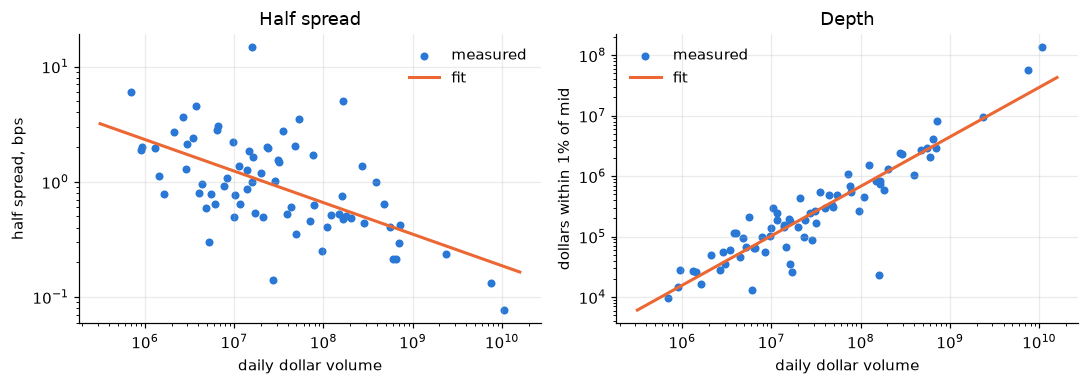

daily volume  half spread bps depth within 1%  one-way cost, $10k trade  one-way cost, $100k trade
         $1M             2.33            $16k                     39.30                     327.03
         $3M             1.72            $38k                     19.73                     136.83
        $10M             1.24           $103k                     11.10                      54.81
        $30M             0.92           $253k                      7.89                      25.68
       $100M             0.66           $678k                      6.40                      13.04
     $1,000M             0.35         $4,460k                      5.46                       6.47
    $10,000M             0.19        $29,359k                      5.20                       5.36


In [3]:
fit = costs.ladder(raw)
a1, b1 = fit['spread']; a2, b2 = fit['depth']
x = np.log10(sample.liquidity)
r1 = np.log10(sample.half_spread_bps) - (a1 + b1 * x)
d = sample.dropna(subset=['depth_1pct_usd'])
r2 = np.log10(d.depth_1pct_usd) - (a2 + b2 * np.log10(d.liquidity))
print(f'half spread   R2 {1 - r1.var() / np.log10(sample.half_spread_bps).var():.2f}   typical miss x{10 ** r1.std():.1f}')
print(f'depth         R2 {1 - r2.var() / np.log10(d.depth_1pct_usd).var():.2f}   typical miss x{10 ** r2.std():.1f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
grid_x = np.logspace(5.5, 10.2, 50)
ax1.scatter(sample.liquidity, sample.half_spread_bps, s=18, color=BLUE, label='measured')
ax1.plot(grid_x, 10 ** (a1 + b1 * np.log10(grid_x)), color=ORANGE, label='fit')
ax1.set_xscale('log'); ax1.set_yscale('log'); ax1.set_xlabel('daily dollar volume'); ax1.set_ylabel('half spread, bps')
ax1.set_title('Half spread'); ax1.legend(frameon=False)
ax2.scatter(d.liquidity, d.depth_1pct_usd, s=18, color=BLUE, label='measured')
ax2.plot(grid_x, 10 ** (a2 + b2 * np.log10(grid_x)), color=ORANGE, label='fit')
ax2.set_xscale('log'); ax2.set_yscale('log'); ax2.set_xlabel('daily dollar volume'); ax2.set_ylabel('dollars within 1% of mid')
ax2.set_title('Depth'); ax2.legend(frameon=False)
plt.tight_layout(); plt.show()

vols = pd.DataFrame({'daily volume': [1e6, 3e6, 1e7, 3e7, 1e8, 1e9, 1e10]})
lv = np.log10(vols['daily volume'])
vols['half spread bps'] = 10 ** (a1 + b1 * lv)
vols['depth within 1%'] = 10 ** (a2 + b2 * lv)
for size in [1e4, 1e5]:
    vols[f'one-way cost, ${size / 1e3:.0f}k trade'] = costs.FEE_BPS + vols['half spread bps'] + 50 * size / vols['depth within 1%']
print(vols.assign(**{'daily volume': vols['daily volume'].map(lambda v: f'${v / 1e6:,.0f}M'),
                     'depth within 1%': vols['depth within 1%'].map(lambda v: f'${v / 1e3:,.0f}k')}).round(2).to_string(index=False))

Depth follows volume closely, an R-squared of 0.84. Half spread follows it loosely, missing about twofold either way. Depth is what matters anyway.

For a small trade on a liquid coin, cost is mostly the fee. A \$10k trade in a \$10M a day coin costs about 10 bps each way, a little above the provisional 7.5. At \$100k it costs about 50 bps, almost all of it impact, because that coin rests only about \$100k within 1% of the price. Cost is a question of size.

The fit is one curve against volume, pooled across dates, so it misses the thinning over time and it is applied to 2020 to 2022 where the archive has no depth at all. Both make the early years look cheaper than they were.

## The books at real cost

Rerun the per coin book on \$10M coins and on \$1M coins, the market book, and the per coin book traded only in moderate months, all at 4 weeks. Price every trade off the ladder for a book of \$100k, \$1M and \$10M, where a coin's trade size is its change in weight times the book. The provisional cost is the first row of each. The later 40% of weeks is reported beside the whole span. It is not a holdout, since every week has been looked at. The moderate months sleeve pays its own switching cost.

In [4]:
from book import Book, halves, sharpe

tb = Book()
W, R, LIQ, VOL, F = tb.W, tb.R, tb.LIQ, tb.VOL, tb.F

def run(w, size=None):
    return tb.run(w, fit=fit, size=size)

moderate = (tb.past_cut(tb.strength()) == 1)
books = {'per coin $10M': tb.per_coin(4), 'per coin $1M': tb.per_coin(4, 1e6), 'market $10M': tb.market(4)}
books['per coin $10M, moderate months only'] = tb.gated(books['per coin $10M'], moderate)

idx = run(books['per coin $10M']).index
later = idx[~halves(idx).values]
rows = []
for name, w in books.items():
    for label, size in [('provisional', None), ('$100k', 1e5), ('$1M', 1e6), ('$10M', 1e7)]:
        r = run(w, size)
        yrs = r.net.groupby(r.net.index.year).apply(sharpe)
        rows.append({'book': name, 'cost': label, 'net': sharpe(r.net), 'later': sharpe(r.net.reindex(later)),
                     'return %': r.net.mean() * 5200, 'cost %': r.cost.mean() * 5200,
                     'losing years': ', '.join(str(y) for y in yrs.index if yrs[y] <= 0) or 'none'})
pd.set_option('display.width', 200)
print(pd.DataFrame(rows).set_index(['book', 'cost']).round(2).to_string())
print()
for label, size in [('$100k', 1e5), ('$1M', 1e6), ('$10M', 1e7)]:
    s = tb.sleeve(books['per coin $10M'], moderate, fit=fit, size=size)
    print(f'moderate months sleeve, {label:5} book   {sharpe(s):+.2f}   later {sharpe(s[s.index.isin(later)]):+.2f}')

                                                  net  later  return %  cost %                  losing years
book                                cost                                                                    
per coin $10M                       provisional  0.85   0.55     44.92   -2.34                          2026
                                    $100k        0.85   0.53     44.58   -2.68                          2026
                                    $1M          0.68   0.16     36.06  -11.19                          2026
                                    $10M        -0.54  -1.40    -49.08  -96.34        2020, 2024, 2025, 2026
per coin $1M                        provisional  0.72   0.32     32.57   -3.14                    2024, 2026
                                    $100k        0.53  -0.16     24.16  -11.55              2023, 2024, 2026
                                    $1M         -1.11  -3.02    -63.72  -99.44        2023, 2024, 2025, 2026
                   

At \$100k, measured cost barely moves the books. The per coin \$10M book makes 0.85, the market book 0.79, and the moderate months book 0.90 with no losing year.

At \$1M, impact bites, hardest on the later weeks where depth is thinnest. The per coin book falls to 0.68 overall and 0.16 later, the market book to 0.70 and 0.45. The moderate months sleeve still makes 1.09, and 1.02 later, and the moderate months book stays positive every year.

At \$10M, every book dies. Impact eats the edge and more.

The \$1M-coin book suffers most. It turns negative in the later weeks from a \$100k book and over the whole span from \$1M, because it trades the coins with the least depth.

## Verdict

Cost does not kill trend at small size and does kill it at large size. The provisional cost matches a book of about \$100k. At \$1M the always-on books keep about 0.7 over the whole span but fall well short on the later weeks, and above that impact takes everything.

That ceiling is conservative. The model treats each weekly rebalance as one order against a single snapshot of the book. Spreading an order over a day meets fresh liquidity and costs less. It also rests on depth measured from 2023 to 2026 and applied back to 2020.

The moderate months sleeve holds to a \$1M book, 1.09 over its weeks and 1.02 in the later ones.